In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
households_df = pd.read_csv("data/household.csv")
households_df.describe()

,HOUSEHOLD_ID,IN_TPB,IN_BMC,HOME_STATE_FIPS,AREA_TYPE,HOME_STATE_COUNTY_FIPS,HOME_TRACT_FIPS,HOME_TPB_TAZ,HOME_BMC_TAZ,HOME_TYPE,...,MPO_HH_INCOME_BROAD,TDATE_DOW,HHTRIPS,PACKAGE_DELIVERED,FOOD_DELIVERED,SERVICE_DELIVERED,WTHHFIN,HOME_OWNERSHIP_IMP,HH_INCOME_DETAILED_IMP,NUMDISABILITIES_IMP
count,1.801500e+04,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,...,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000
mean,1.733655e+08,0.998057,0.560200,33.145157,2.624535,33215.130835,530490.261449,1842.047127,948.396947,1.809270,...,-0.005051,2.996336,7.054399,0.242687,0.028698,0.055121,149.339694,-0.935332,-0.728893,-0.920899
std,1.135731e+07,0.044036,0.496377,14.974619,4.459310,15037.845994,305048.127741,1093.660828,1004.654531,0.900965,...,4.091130,1.418207,5.486647,0.428719,0.166962,0.228222,116.604905,2.777106,2.754609,2.770127
min,1.400003e+08,0.000000,0.000000,11.000000,0.000000,11001.000000,100.000000,-9.000000,-9.000000,-9.000000,...,-9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,9.000000,-9.000000,-9.000000,-9.000000
25%,1.700568e+08,1.000000,0.000000,24.000000,0.000000,24017.000000,201600.000000,799.000000,-9.000000,1.000000,...,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,78.000000,0.000000,0.000000,0.000000
50%,1.800420e+08,1.000000,1.000000,24.000000,1.000000,24033.000000,611208.000000,1757.000000,499.000000,2.000000,...,2.000000,3.000000,6.000000,0.000000,0.000000,0.000000,125.000000,0.000000,0.000000,0.000000
75%,1.801498e+08,1.000000,1.000000,51.000000,1.000000,51059.000000,752203.000000,2984.000000,1902.000000,3.000000,...,2.000000,4.000000,10.000000,0.000000,0.000000,0.000000,181.867322,0.000000,0.000000,0.000000
max,1.802569e+08,1.000000,1.000000,54.000000,13.000000,54037.000000,972800.000000,3675.000000,2934.000000,5.000000,...,2.000000,5.000000,53.000000,1.000000,1.000000,1.000000,2554.000000,1.000000,1.000000,1.000000


In [40]:
print("unique state codes: ", households_df["HOME_STATE_FIPS"].unique())
print("unique county codes: ", households_df["HOME_STATE_COUNTY_FIPS"].unique())

unique state codes:  [24 11 51 54]
unique county codes:  [24003 24013 24027 11001 24033 24031 51683 54037 51153 51059 51177 51179
 51013 51061 24017 24021 24009 51107 51610 51510 24037 51630 51600 51099
 51043 51685]


### State FIPS lookup (4 states in dataset)

| FIPS | State |
|---|---|
| 11 | District of Columbia (DC) |
| 24 | Maryland (MD) |
| 51 | Virginia (VA) |
| 54 | West Virginia (WV) |

### County FIPS lookup (26 counties in dataset)

| FIPS | County | State |
|---|---|---|
| 11001 | District of Columbia | DC |
| 24003 | Anne Arundel | MD |
| 24009 | Calvert | MD |
| 24013 | Carroll | MD |
| 24017 | Charles | MD |
| 24021 | Frederick | MD |
| 24027 | Howard | MD |
| 24031 | Montgomery | MD |
| 24033 | Prince George's | MD |
| 24037 | St. Mary's | MD |
| 51013 | Arlington | VA |
| 51043 | Clarke | VA |
| 51059 | Fairfax (county) | VA |
| 51061 | Fauquier | VA |
| 51099 | King George | VA |
| 51107 | Loudoun | VA |
| 51153 | Prince William | VA |
| 51177 | Spotsylvania | VA |
| 51179 | Stafford | VA |
| 51510 | Alexandria (city) | VA |
| 51600 | Fairfax (city) | VA |
| 51610 | Falls Church (city) | VA |
| 51630 | Fredericksburg (city) | VA |
| 51683 | Manassas (city) | VA |
| 51685 | Manassas Park (city) | VA |
| 54037 | Jefferson | WV |

*Note: VA `515xx`/`516xx` = independent cities (county-equivalents, separate FIPS from surrounding county). Fairfax city `51600` ≠ Fairfax county `51059`.*

Source (US Census): https://transition.fcc.gov/oet/info/maps/census/fips/fips.txt

#### __We need to decide which county the this study should be based on. For now, this notebook will use Fairfax County. Can be changed later.__

In [41]:
COUNTY_CODE = 51059 # Fairfax county
fx_households = households_df[households_df["HOME_STATE_COUNTY_FIPS"] == COUNTY_CODE]
fx_households.describe()

,HOUSEHOLD_ID,IN_TPB,IN_BMC,HOME_STATE_FIPS,AREA_TYPE,HOME_STATE_COUNTY_FIPS,HOME_TRACT_FIPS,HOME_TPB_TAZ,HOME_BMC_TAZ,HOME_TYPE,...,MPO_HH_INCOME_BROAD,TDATE_DOW,HHTRIPS,PACKAGE_DELIVERED,FOOD_DELIVERED,SERVICE_DELIVERED,WTHHFIN,HOME_OWNERSHIP_IMP,HH_INCOME_DETAILED_IMP,NUMDISABILITIES_IMP
count,2.123000e+03,2123.0,2123.0,2123.0,2123.000000,2123.0,2123.000000,2123.000000,2123.0,2123.000000,...,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000
mean,1.765091e+08,1.0,0.0,51.0,0.401319,51059.0,458291.259538,1887.641074,-9.0,1.785210,...,1.897786,3.011776,7.083373,0.265191,0.026849,0.067829,190.881771,0.018841,0.189826,0.021196
std,4.835817e+06,0.0,0.0,0.0,0.490281,0.0,25948.788925,163.262968,0.0,0.857427,...,0.303001,1.420648,5.492701,0.441539,0.161679,0.251511,131.893249,0.135996,0.392256,0.144073
min,1.700005e+08,1.0,0.0,51.0,0.000000,51059.0,415100.000000,1611.000000,-9.0,1.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,61.000000,0.000000,0.000000,0.000000
25%,1.700771e+08,1.0,0.0,51.0,0.000000,51059.0,431802.000000,1739.000000,-9.0,1.000000,...,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000,105.000000,0.000000,0.000000,0.000000
50%,1.800580e+08,1.0,0.0,51.0,0.000000,51059.0,461100.000000,1903.000000,-9.0,2.000000,...,2.000000,3.000000,6.000000,0.000000,0.000000,0.000000,161.000000,0.000000,0.000000,0.000000
75%,1.801590e+08,1.0,0.0,51.0,1.000000,51059.0,481900.000000,2038.000000,-9.0,3.000000,...,2.000000,4.000000,10.000000,1.000000,0.000000,0.000000,241.500000,0.000000,0.000000,0.000000
max,1.802569e+08,1.0,0.0,51.0,1.000000,51059.0,492500.000000,2158.000000,-9.0,4.000000,...,2.000000,5.000000,48.000000,1.000000,1.000000,1.000000,1793.000000,1.000000,1.000000,1.000000


### Households in fx county data exploration

In [42]:
sns.set_theme(style="darkgrid", context="notebook")
plt.style.use("dark_background")

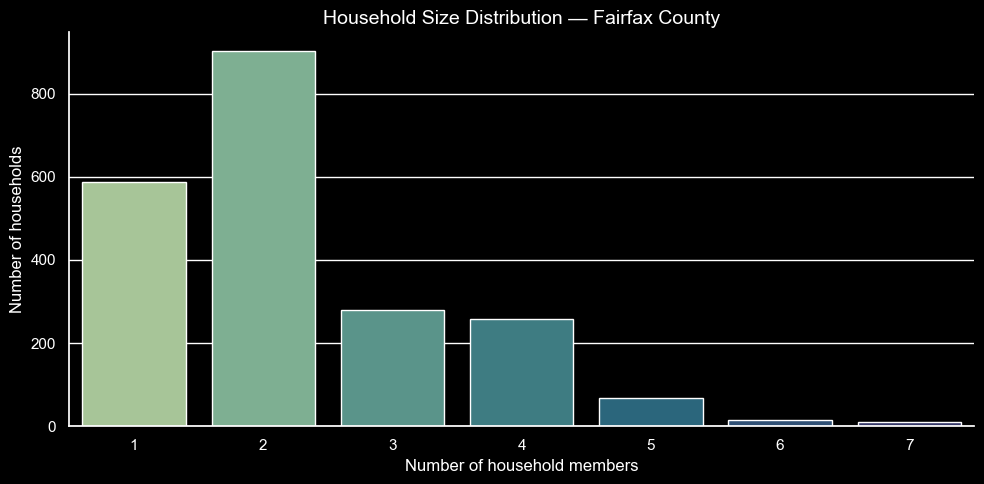

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
size_order = sorted(fx_households["HHSIZE"].unique())
sns.countplot(data = fx_households, x = "HHSIZE", order = size_order, hue = "HHSIZE", palette = "crest", legend = False, ax = ax)
ax.set_xticks(range(len(size_order)))
ax.set_xticklabels([str(s) if s < 8 else "8+" for s in size_order])
ax.set_title("Household Size Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Number of household members")
ax.set_ylabel("Number of households")
sns.despine()
plt.tight_layout()
plt.show()

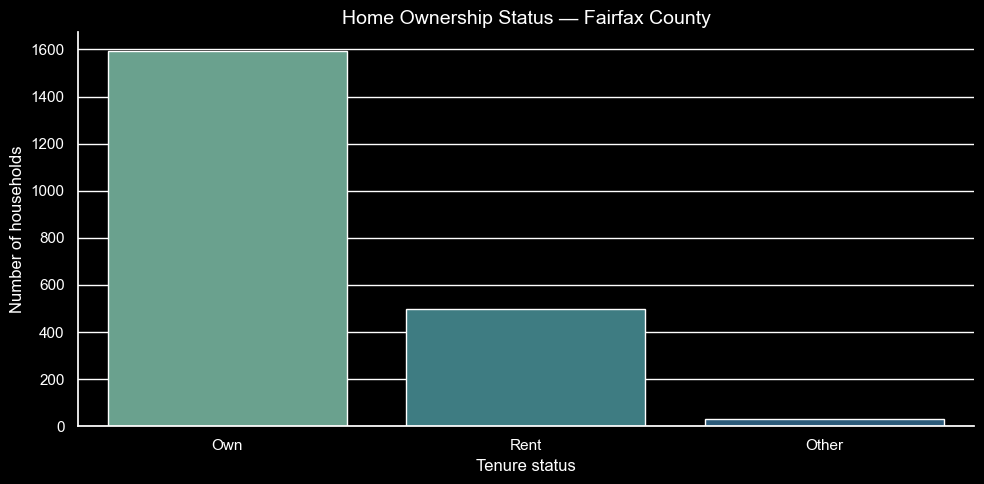

In [44]:
ownership_labels = {1: "Own", 2: "Rent", 3: "Other"}
ownership_order = ["Own", "Rent", "Other"]
ownership_data = fx_households[fx_households["HOME_OWNERSHIP"] != -9].copy()
ownership_data["Ownership"] = ownership_data["HOME_OWNERSHIP"].map(ownership_labels)
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = ownership_data, x = "Ownership", order = ownership_order, hue = "Ownership", palette = "crest", legend = False, ax = ax)
ax.set_title("Home Ownership Status — Fairfax County", fontsize = 14)
ax.set_xlabel("Tenure status")
ax.set_ylabel("Number of households")
sns.despine()
plt.tight_layout()
plt.show()

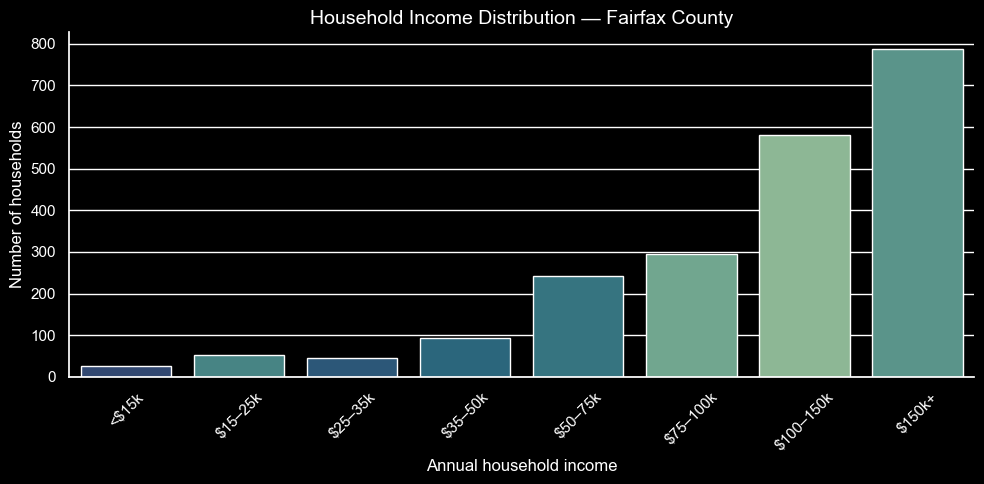

In [45]:
income_labels = {
    1: "<$15k", 2: "$15–25k", 3: "$25–35k", 4: "$35–50k",
    5: "$50–75k", 6: "$75–100k", 7: "$100–150k", 8: "$150k+",
}
income_order = [income_labels[i] for i in range(1, 9)]
income_data = fx_households.copy()
income_data["Income"] = income_data["HH_INCOME_DETAILED"].map(income_labels)
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = income_data, x = "Income", order = income_order, hue = "Income", palette = "crest", legend = False, ax = ax)
ax.set_title("Household Income Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Annual household income")
ax.set_ylabel("Number of households")
ax.tick_params(axis = "x", rotation = 45)
sns.despine()
plt.tight_layout()
plt.show()

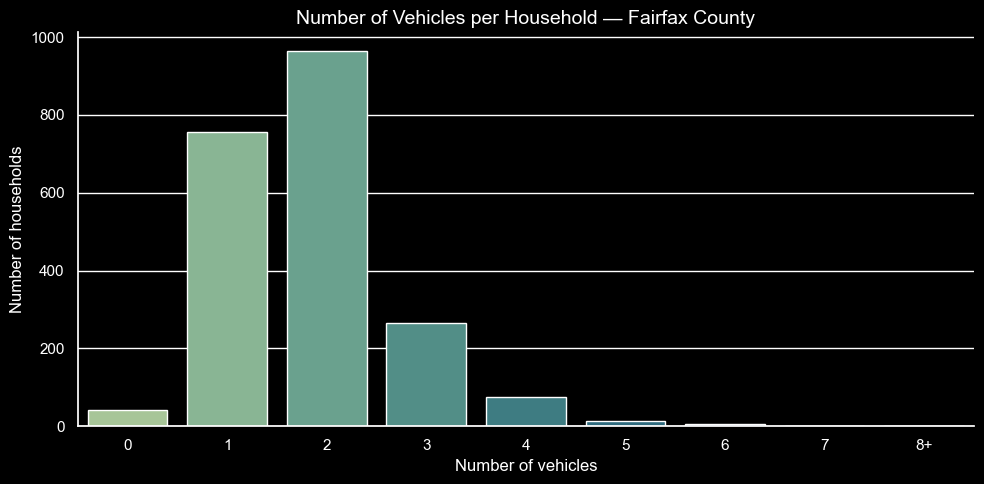

In [46]:
fig, ax = plt.subplots(figsize = (10, 5))
vehicle_order = sorted(fx_households["NUMVEHICLE"].unique())

sns.countplot(data = fx_households, x = "NUMVEHICLE", order = vehicle_order, hue = "NUMVEHICLE", palette="crest", legend = False, ax = ax)
ax.set_xticks(range(len(vehicle_order)))
ax.set_xticklabels([str(v) if v < 8 else "8+" for v in vehicle_order])
ax.set_title("Number of Vehicles per Household — Fairfax County", fontsize = 14)
ax.set_xlabel("Number of vehicles")
ax.set_ylabel("Number of households")

sns.despine()
plt.tight_layout()
plt.show()

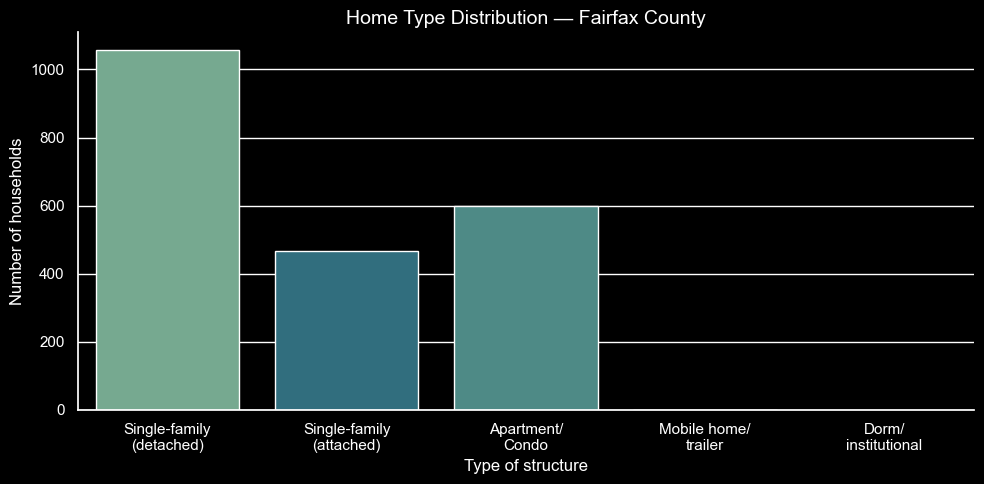

In [47]:
home_type_labels = {
    1: "Single-family\n(detached)", 2: "Single-family\n(attached)",
    3: "Apartment/\nCondo", 4: "Mobile home/\ntrailer", 5: "Dorm/\ninstitutional",
}
home_type_order = [home_type_labels[i] for i in range(1, 6)]
home_type_data = fx_households[fx_households["HOME_TYPE"] != -9].copy()
home_type_data["HomeType"] = home_type_data["HOME_TYPE"].map(home_type_labels)
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = home_type_data, x = "HomeType", order = home_type_order, hue = "HomeType", palette = "crest", legend = False, ax = ax)
ax.set_title("Home Type Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Type of structure")
ax.set_ylabel("Number of households")
sns.despine()
plt.tight_layout()
plt.show()

### People in fx county data exploration

In [48]:
person_df = pd.read_csv("data/person.csv")
person_df = person_df[person_df["HOUSEHOLD_ID"].isin(fx_households["HOUSEHOLD_ID"])]
person_df.describe()


,HOUSEHOLD_ID,PERSON_ID,AGE,AGE_GROUP,GENDER,RACEETHNICITY,MPO_RACEETHNICITY,RACEETHNICITY_HISPANIC,MPO_RACEETHNICITY_HISPANIC,LICENSE,...,MPO_TD_SHOP_TIME,PERSON_TRIPCOUNT,WALK_BIKE_LOOP_TRIPS,WTPERFIN,WWM_WTPERFIN,AGE_IMP,GENDER_IMP,RACEETHNICITY_IMP,MPO_RACEETHNICITY_IMP,DISABILITY_IMP
count,4.778000e+03,4.778000e+03,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,...,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000,4778.000000
mean,1.764885e+08,1.764885e+10,43.036417,7.900795,1.489745,3.615320,4.857681,1.891377,6.528045,1.209293,...,7.143993,3.147342,-1.298870,234.474048,234.894307,0.007744,0.005023,0.105065,0.105065,0.013185
std,4.841433e+06,4.841433e+08,22.487471,3.093714,0.499947,0.857549,14.407329,0.776813,67.440210,0.406846,...,22.520295,2.347294,3.656465,171.990608,177.328682,0.087667,0.070702,0.306669,0.306669,0.114080
min,1.700005e+08,1.700005e+10,0.000000,1.000000,1.000000,1.000000,1.000000,-9.000000,1.000000,1.000000,...,-9.000000,0.000000,-9.000000,61.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.700765e+08,1.700765e+10,27.000000,7.000000,1.000000,3.000000,5.000000,2.000000,2.000000,1.000000,...,0.000000,2.000000,0.000000,133.000000,129.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.800591e+08,1.800591e+10,45.000000,9.000000,1.000000,4.000000,5.000000,2.000000,2.000000,1.000000,...,0.000000,3.000000,0.000000,175.000000,179.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.801583e+08,1.801583e+10,62.000000,10.000000,2.000000,4.000000,5.000000,2.000000,2.000000,1.000000,...,0.000000,4.000000,0.000000,284.000000,290.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.802569e+08,1.802569e+10,99.000000,13.000000,2.000000,5.000000,997.000000,2.000000,998.000000,2.000000,...,360.000000,23.000000,4.000000,1793.000000,1806.000000,1.000000,1.000000,1.000000,1.000000,1.000000


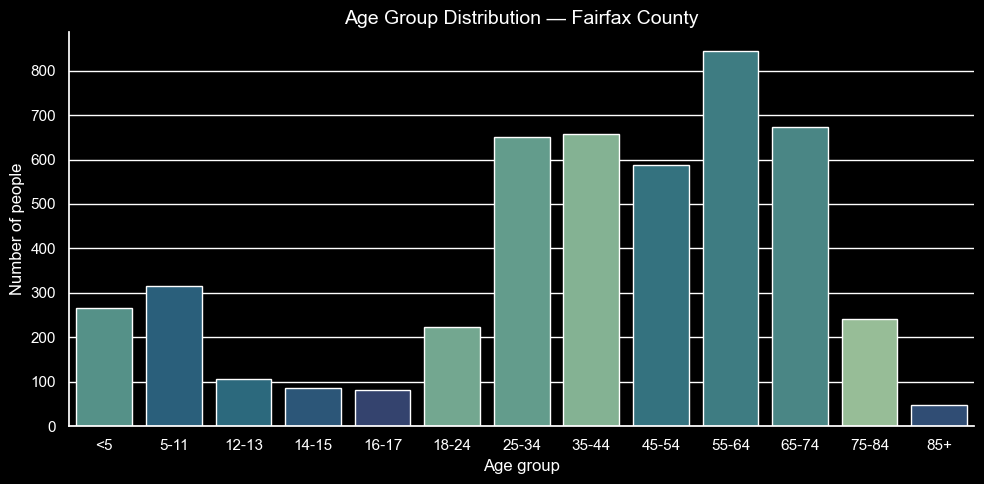

In [49]:
age_group_labels = {
    1: "<5", 2: "5-11", 3: "12-13", 4: "14-15", 5: "16-17", 6: "18-24",
    7: "25-34", 8: "35-44", 9: "45-54", 10: "55-64", 11: "65-74", 12: "75-84", 13: "85+",
}
age_group_data = person_df[person_df["AGE_GROUP"] != -9].copy()
age_group_data["AgeGroup"] = age_group_data["AGE_GROUP"].map(age_group_labels)
age_group_order = [age_group_labels[c] for c in sorted(age_group_data["AGE_GROUP"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = age_group_data, x = "AgeGroup", order = age_group_order, hue = "AgeGroup", palette = "crest", legend = False, ax = ax)
ax.set_title("Age Group Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Age group")
ax.set_ylabel("Number of people")
sns.despine()
plt.tight_layout()
plt.show()

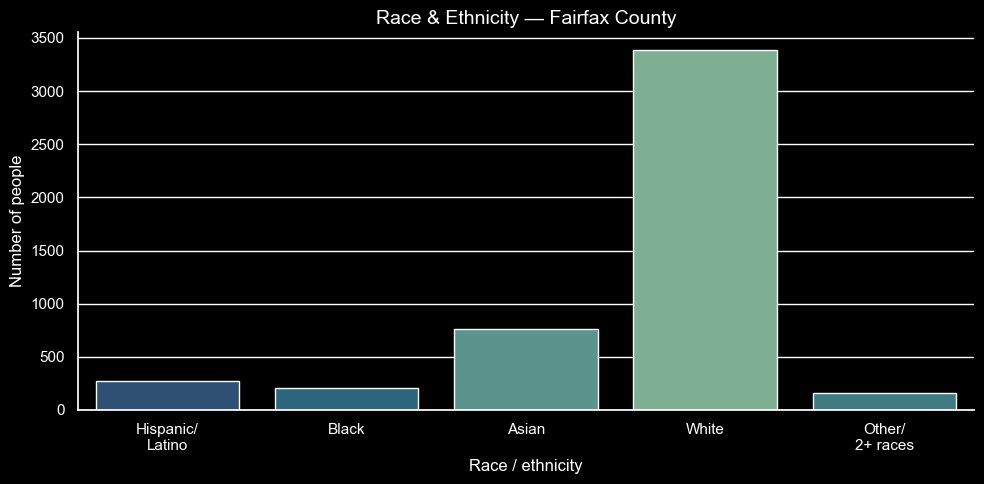

In [50]:
race_labels = {
    1: "Hispanic/\nLatino", 2: "Black", 3: "Asian", 4: "White", 5: "Other/\n2+ races",
}
race_data = person_df[person_df["RACEETHNICITY"] != -9].copy()
race_data["RaceEthnicity"] = race_data["RACEETHNICITY"].map(race_labels)
race_order = [race_labels[c] for c in sorted(race_data["RACEETHNICITY"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = race_data, x = "RaceEthnicity", order = race_order, hue = "RaceEthnicity", palette = "crest", legend = False, ax = ax)
ax.set_title("Race & Ethnicity — Fairfax County", fontsize = 14)
ax.set_xlabel("Race / ethnicity")
ax.set_ylabel("Number of people")
sns.despine()
plt.tight_layout()
plt.show()

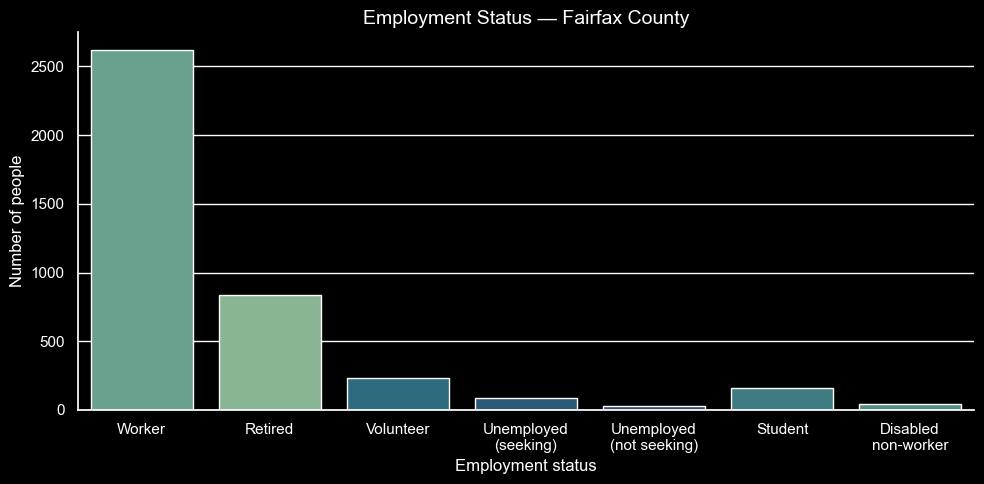

In [51]:
employment_labels = {
    0: "Worker", 1: "Retired", 2: "Volunteer", 3: "Homemaker",
    4: "Unemployed\n(seeking)", 5: "Unemployed\n(not seeking)", 6: "Student", 7: "Disabled\nnon-worker",
}
employment_data = person_df[person_df["EMPLOYMENT_STATUS"] != -9].copy()
employment_data["Employment"] = employment_data["EMPLOYMENT_STATUS"].map(employment_labels)
employment_order = [employment_labels[c] for c in sorted(employment_data["EMPLOYMENT_STATUS"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = employment_data, x = "Employment", order = employment_order, hue = "Employment", palette = "crest", legend = False, ax = ax)
ax.set_title("Employment Status — Fairfax County", fontsize = 14)
ax.set_xlabel("Employment status")
ax.set_ylabel("Number of people")
sns.despine()
plt.tight_layout()
plt.show()

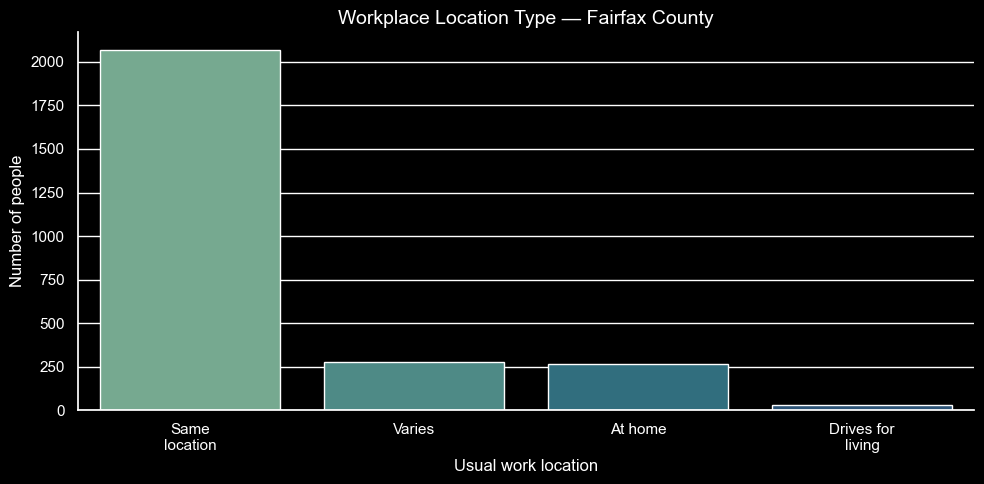

In [52]:
workplace_loc_labels = {
    1: "Same\nlocation", 2: "Varies", 3: "At home", 4: "Drives for\nliving",
}
workplace_loc_data = person_df[person_df["J1_WORKPLACE_LOC"] != -9].copy()
workplace_loc_data["WorkplaceLoc"] = workplace_loc_data["J1_WORKPLACE_LOC"].map(workplace_loc_labels)
workplace_loc_order = [workplace_loc_labels[c] for c in sorted(workplace_loc_data["J1_WORKPLACE_LOC"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = workplace_loc_data, x = "WorkplaceLoc", order = workplace_loc_order, hue = "WorkplaceLoc", palette = "crest", legend = False, ax = ax)
ax.set_title("Workplace Location Type — Fairfax County", fontsize = 14)
ax.set_xlabel("Usual work location")
ax.set_ylabel("Number of people")
sns.despine()
plt.tight_layout()
plt.show()

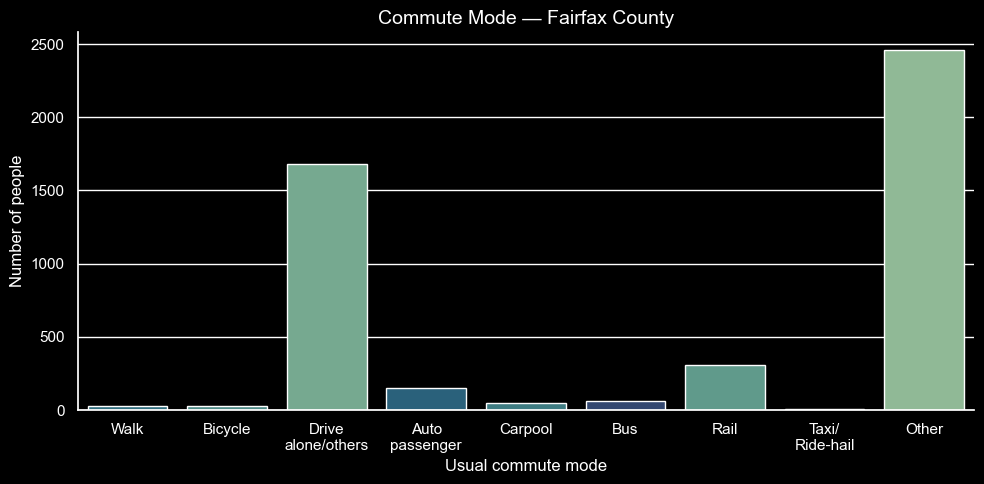

In [53]:
commute_mode_labels = {
    1: "Walk", 2: "Bicycle", 3: "Drive\nalone/others", 4: "Auto\npassenger", 5: "Carpool",
    6: "Bus", 7: "Rail", 8: "Taxi/\nRide-hail", 9: "Other",
}
commute_mode_data = person_df[person_df["J1_COMMUTE_MODE"] != -9].copy()
commute_mode_data["CommuteMode"] = commute_mode_data["J1_COMMUTE_MODE"].map(commute_mode_labels)
commute_mode_order = [commute_mode_labels[c] for c in sorted(commute_mode_data["J1_COMMUTE_MODE"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = commute_mode_data, x = "CommuteMode", order = commute_mode_order, hue = "CommuteMode", palette = "crest", legend = False, ax = ax)
ax.set_title("Commute Mode — Fairfax County", fontsize = 14)
ax.set_xlabel("Usual commute mode")
ax.set_ylabel("Number of people")
sns.despine()
plt.tight_layout()
plt.show()

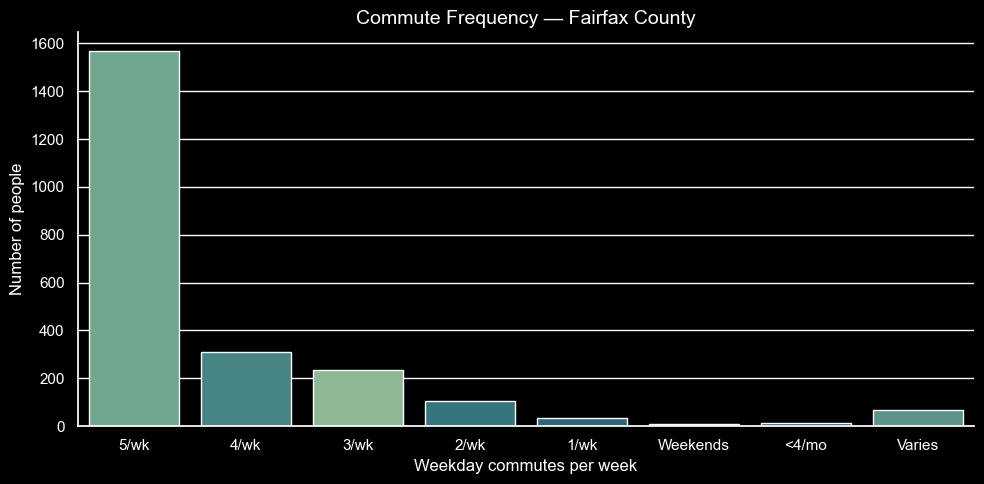

In [54]:
commute_freq_labels = {
    1: "5/wk", 2: "4/wk", 3: "3/wk", 4: "2/wk", 5: "1/wk",
    6: "Weekends", 7: "<4/mo", 8: "Varies",
}
commute_freq_data = person_df[person_df["J1_COMMUTE_FREQ"] != -9].copy()
commute_freq_data["CommuteFreq"] = commute_freq_data["J1_COMMUTE_FREQ"].map(commute_freq_labels)
commute_freq_order = [commute_freq_labels[c] for c in sorted(commute_freq_data["J1_COMMUTE_FREQ"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = commute_freq_data, x = "CommuteFreq", order = commute_freq_order, hue = "CommuteFreq", palette = "crest", legend = False, ax = ax)
ax.set_title("Commute Frequency — Fairfax County", fontsize = 14)
ax.set_xlabel("Weekday commutes per week")
ax.set_ylabel("Number of people")
sns.despine()
plt.tight_layout()
plt.show()

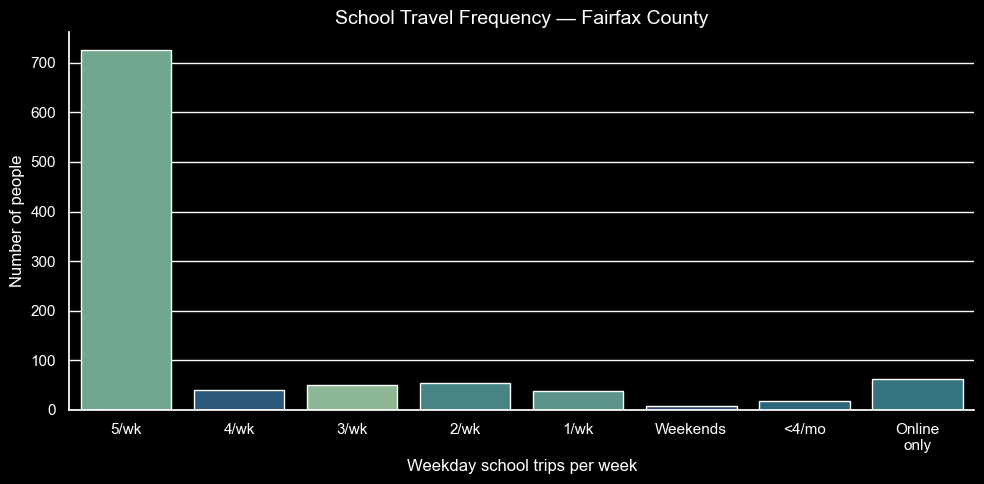

In [55]:
school_freq_labels = {
    1: "5/wk", 2: "4/wk", 3: "3/wk", 4: "2/wk", 5: "1/wk",
    6: "Weekends", 7: "<4/mo", 8: "Online\nonly",
}
school_freq_data = person_df[person_df["SCHOOL_FREQ"] != -9].copy()
school_freq_data["SchoolFreq"] = school_freq_data["SCHOOL_FREQ"].map(school_freq_labels)
school_freq_order = [school_freq_labels[c] for c in sorted(school_freq_data["SCHOOL_FREQ"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = school_freq_data, x = "SchoolFreq", order = school_freq_order, hue = "SchoolFreq", palette = "crest", legend = False, ax = ax)
ax.set_title("School Travel Frequency — Fairfax County", fontsize = 14)
ax.set_xlabel("Weekday school trips per week")
ax.set_ylabel("Number of people")
sns.despine()
plt.tight_layout()
plt.show()

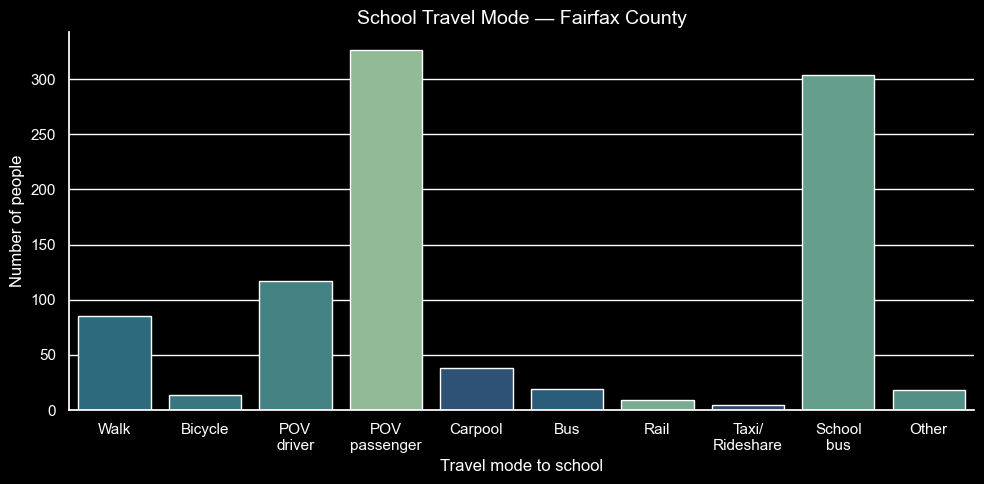

In [56]:
school_mode_labels = {
    1: "Walk", 2: "Bicycle", 3: "POV\ndriver", 4: "POV\npassenger", 5: "Carpool",
    6: "Bus", 7: "Rail", 8: "Taxi/\nRideshare", 9: "School\nbus", 10: "Other",
}
school_mode_data = person_df[person_df["SCHOOL_MODE"] != -9].copy()
school_mode_data["SchoolMode"] = school_mode_data["SCHOOL_MODE"].map(school_mode_labels)
school_mode_order = [school_mode_labels[c] for c in sorted(school_mode_data["SCHOOL_MODE"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = school_mode_data, x = "SchoolMode", order = school_mode_order, hue = "SchoolMode", palette = "crest", legend = False, ax = ax)
ax.set_title("School Travel Mode — Fairfax County", fontsize = 14)
ax.set_xlabel("Travel mode to school")
ax.set_ylabel("Number of people")
sns.despine()
plt.tight_layout()
plt.show()

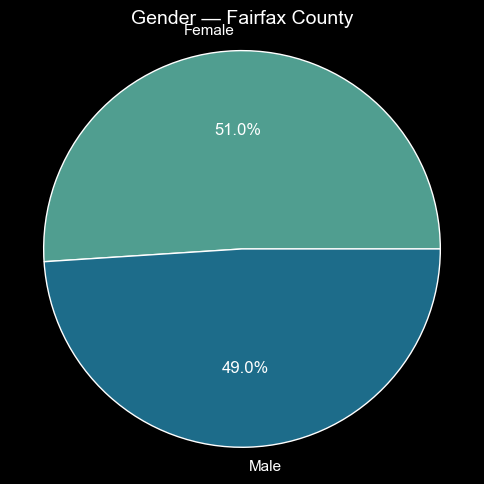

In [57]:
gender_labels = {1: "Female", 2: "Male"}
gender_counts = person_df[person_df["GENDER"] != -9]["GENDER"].map(gender_labels).value_counts()
fig, ax = plt.subplots(figsize = (5, 5))
ax.pie(gender_counts, labels = gender_counts.index, autopct = "%1.1f%%", colors = sns.color_palette("crest", len(gender_counts)))
ax.set_title("Gender — Fairfax County", fontsize = 14)
ax.axis("equal")
plt.tight_layout()
plt.show()

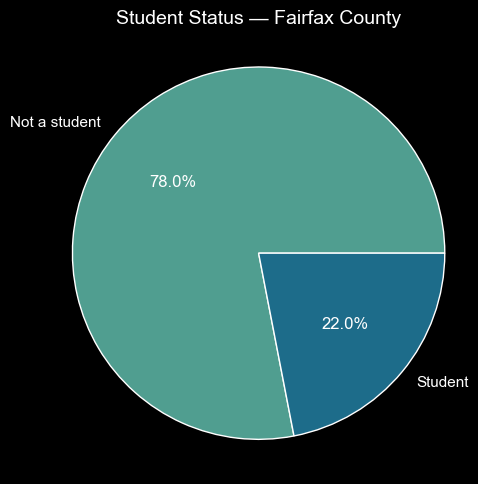

In [58]:
student_labels = {0: "Not a student", 1: "Student"}
student_counts = person_df[person_df["STUDENT_STATUS"] != -9]["STUDENT_STATUS"].map(student_labels).value_counts()
fig, ax = plt.subplots(figsize = (5, 5))
ax.pie(student_counts, labels = student_counts.index, autopct = "%1.1f%%", colors = sns.color_palette("crest", len(student_counts)))
ax.set_title("Student Status — Fairfax County", fontsize = 14)
ax.axis("equal")
plt.tight_layout()
plt.show()

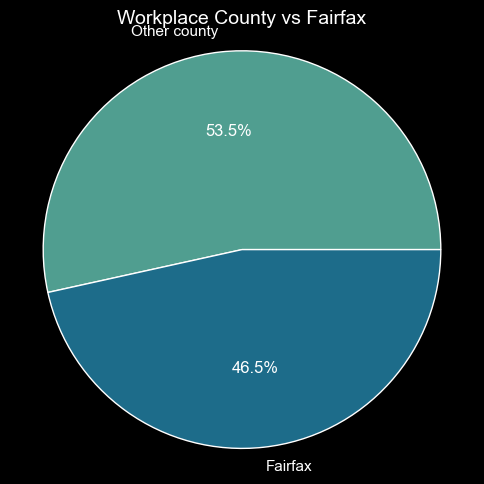

In [59]:
work_county_data = person_df[person_df["WORK_STATE_COUNTY_FIPS"] != -9]
work_county_counts = work_county_data["WORK_STATE_COUNTY_FIPS"].eq(COUNTY_CODE).map({True: "Fairfax", False: "Other county"}).value_counts()
fig, ax = plt.subplots(figsize = (5, 5))
ax.pie(work_county_counts, labels = work_county_counts.index, autopct = "%1.1f%%", colors = sns.color_palette("crest", len(work_county_counts)))
ax.set_title("Workplace County vs Fairfax", fontsize = 14)
ax.axis("equal")
plt.tight_layout()
plt.show()

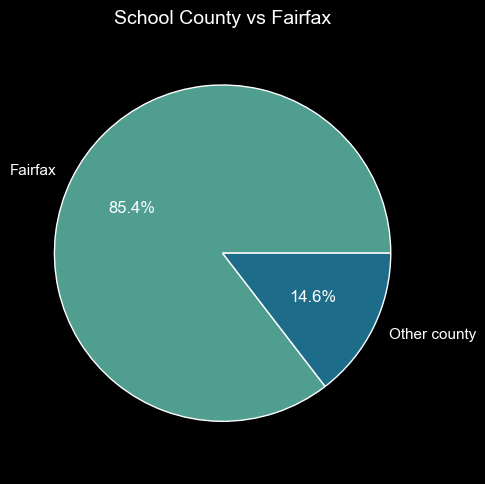

In [60]:
school_county_data = person_df[person_df["SCHOOL_STATE_COUNTY_FIPS"] != -9]
school_county_counts = school_county_data["SCHOOL_STATE_COUNTY_FIPS"].eq(COUNTY_CODE).map({True: "Fairfax", False: "Other county"}).value_counts()
fig, ax = plt.subplots(figsize = (5, 5))
ax.pie(school_county_counts, labels = school_county_counts.index, autopct = "%1.1f%%", colors = sns.color_palette("crest", len(school_county_counts)))
ax.set_title("School County vs Fairfax", fontsize = 14)
ax.axis("equal")
plt.tight_layout()
plt.show()

### Vehicles in fx county data exploration

In [61]:
vehicles_df = pd.read_csv("data/vehicle.csv")
vehicles_df = vehicles_df[vehicles_df["HOUSEHOLD_ID"].isin(fx_households["HOUSEHOLD_ID"])]
vehicles_df.describe()

,HOUSEHOLD_ID,VEHNUM,YEAR,BODYTYPE,FUELTYPE,TOLLTRANSPONDER,MPO_TOLLTRANSPONDER,WTHHFIN
count,3.900000e+03,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1.764923e+08,1.636410,2009.636923,1.928974,1.249231,1.369744,2.314103,205.212308
std,4.839444e+06,0.832839,6.471114,1.210720,0.860603,0.482797,1.346604,137.043404
min,1.700005e+08,1.000000,1980.000000,1.000000,1.000000,1.000000,1.000000,61.000000
25%,1.700773e+08,1.000000,2006.000000,1.000000,1.000000,1.000000,1.000000,131.000000
50%,1.800585e+08,1.000000,2011.000000,1.000000,1.000000,1.000000,2.000000,164.000000
75%,1.801581e+08,2.000000,2015.000000,3.000000,1.000000,2.000000,4.000000,247.000000
max,1.802569e+08,8.000000,2019.000000,7.000000,6.000000,2.000000,4.000000,1252.000000


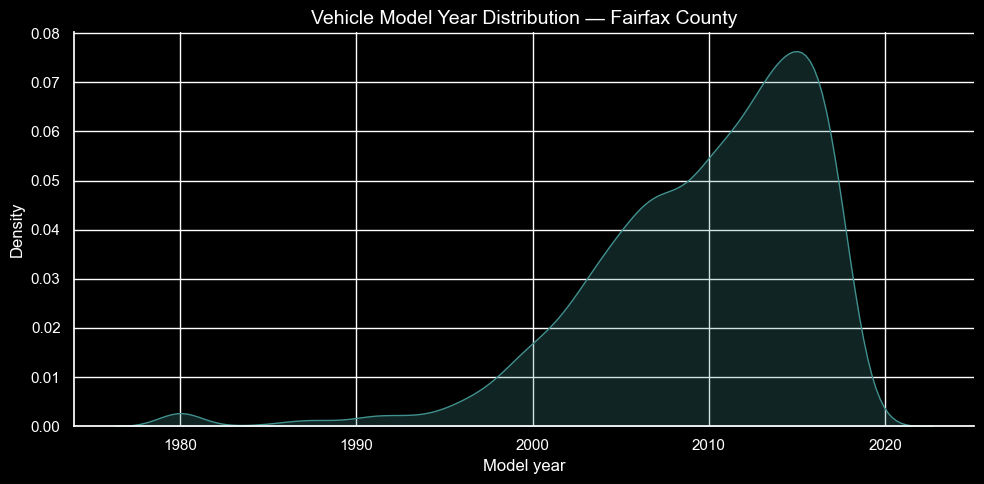

In [62]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.kdeplot(data = vehicles_df[vehicles_df["YEAR"] != -9], x = "YEAR", fill = True, color = sns.color_palette("crest")[2], ax = ax)
ax.set_title("Vehicle Model Year Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Model year")
ax.set_ylabel("Density")
sns.despine()
plt.tight_layout()
plt.show()

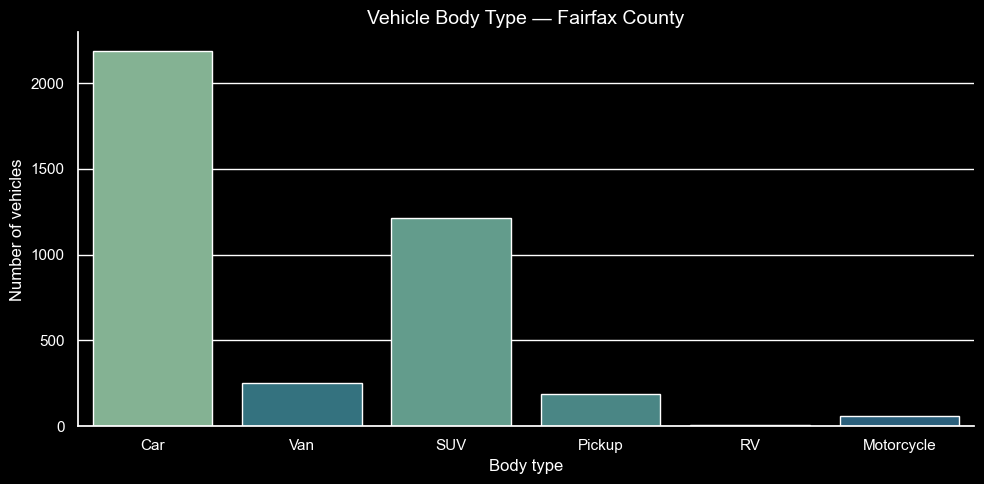

In [63]:
bodytype_labels = {
    1: "Car", 2: "Van", 3: "SUV", 4: "Pickup", 5: "Other\ntruck", 6: "RV", 7: "Motorcycle", 997: "Other",
}
bodytype_data = vehicles_df[vehicles_df["BODYTYPE"] != -9].copy()
bodytype_data["BodyType"] = bodytype_data["BODYTYPE"].map(bodytype_labels)
bodytype_order = [bodytype_labels[c] for c in sorted(bodytype_data["BODYTYPE"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = bodytype_data, x = "BodyType", order = bodytype_order, hue = "BodyType", palette = "crest", legend = False, ax = ax)
ax.set_title("Vehicle Body Type — Fairfax County", fontsize = 14)
ax.set_xlabel("Body type")
ax.set_ylabel("Number of vehicles")
sns.despine()
plt.tight_layout()
plt.show()

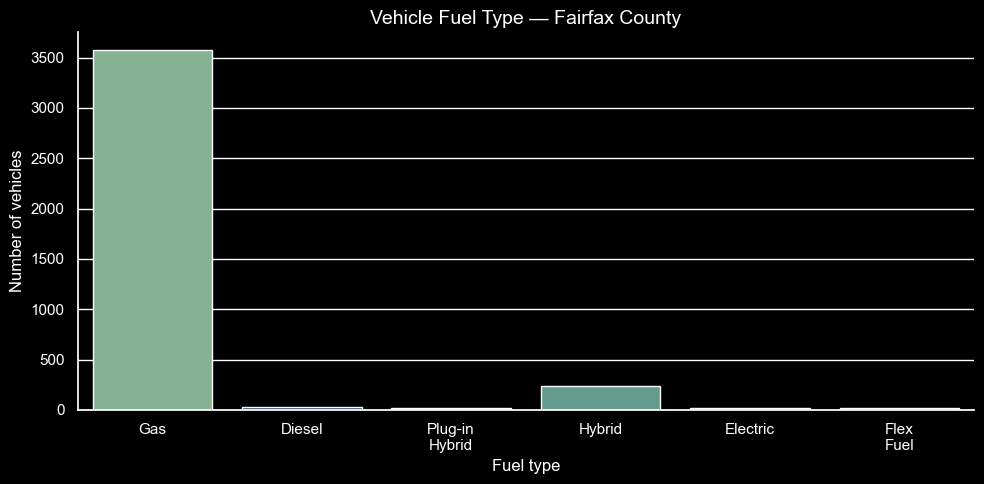

In [64]:
fueltype_labels = {
    1: "Gas", 2: "Diesel", 3: "Plug-in\nHybrid", 4: "Hybrid", 5: "Electric", 6: "Flex\nFuel", 997: "Other",
}
fueltype_data = vehicles_df[vehicles_df["FUELTYPE"] != -9].copy()
fueltype_data["FuelType"] = fueltype_data["FUELTYPE"].map(fueltype_labels)
fueltype_order = [fueltype_labels[c] for c in sorted(fueltype_data["FUELTYPE"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = fueltype_data, x = "FuelType", order = fueltype_order, hue = "FuelType", palette = "crest", legend = False, ax = ax)
ax.set_title("Vehicle Fuel Type — Fairfax County", fontsize = 14)
ax.set_xlabel("Fuel type")
ax.set_ylabel("Number of vehicles")
sns.despine()
plt.tight_layout()
plt.show()

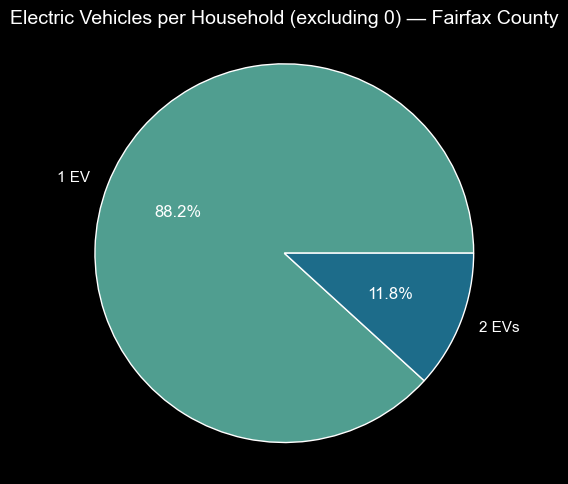

In [65]:
ev_per_hh = vehicles_df[vehicles_df["FUELTYPE"] == 5].groupby("HOUSEHOLD_ID").size()
ev_pie_counts = ev_per_hh.value_counts().sort_index()
ev_pie_labels = [f"{n} EV" if n == 1 else f"{n} EVs" for n in ev_pie_counts.index]
fig, ax = plt.subplots(figsize = (5, 5))
ax.pie(ev_pie_counts, labels = ev_pie_labels, autopct = "%1.1f%%", colors = sns.color_palette("crest", len(ev_pie_counts)))
ax.set_title("Electric Vehicles per Household (excluding 0) — Fairfax County", fontsize = 14)
ax.axis("equal")
plt.tight_layout()
plt.show()

### Trips in fx county data exploration

In [66]:
trips_df = pd.read_csv("data/trip.csv")
trips_df = trips_df[trips_df["HOUSEHOLD_ID"].isin(fx_households["HOUSEHOLD_ID"])]
trips_df.describe()

,HOUSEHOLD_ID,PERSON_ID,PERSNO,TRIPID,TRIPNO,O_PURPOSE,O_ACTIVITY,MPO_O_ACTIVITY,O_STATE_FIPS,O_STATE_COUNTY_FIPS,...,SUBWAY_STATION_BOARD,SUBWAY_ACCESS_MODE,SUBWAY_STATION_EXIT,SUBWAY_EGRESS_MODE,HOV_USED,TOLL_ROAD_USED,DISTANCE,REPORTED_TRAVEL_TIME,WTTRDFIN,WWM_WTTRDFIN
count,1.503800e+04,1.503800e+04,15038.000000,1.503800e+04,15038.000000,15038.000000,15038.000000,15038.000000,15038.000000,15038.000000,...,15038.000000,15038.000000,15038.000000,15038.000000,15038.000000,15038.000000,15038.000000,15038.000000,15038.000000,15038.000000
mean,1.763890e+08,1.763890e+10,1.773308,1.763890e+12,3.043024,5.543091,5.160394,18.327105,48.430975,48513.515494,...,-6.589972,-8.629406,-6.591967,-8.630270,-8.895598,-8.713393,10.666463,24.152480,229.246841,229.474465
std,4.869035e+06,4.869035e+08,1.022920,4.869035e+10,2.127779,10.907379,5.169747,106.978885,9.420277,9441.046285,...,14.844170,1.970955,14.829438,1.966574,1.016460,1.668566,104.917456,34.605937,165.526727,171.418232
min,1.700005e+08,1.700005e+10,1.000000,1.700005e+12,1.000000,1.000000,1.000000,1.000000,6.000000,6000.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,0.000000,5.000000,61.000000,19.000000
25%,1.700728e+08,1.700728e+10,1.000000,1.700728e+12,1.000000,1.000000,1.000000,1.000000,51.000000,51059.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,1.234603,10.000000,132.000000,120.000000
50%,1.800550e+08,1.800550e+10,1.000000,1.800550e+12,2.000000,2.500000,2.000000,3.000000,51.000000,51059.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.249352,15.000000,175.000000,177.000000
75%,1.801581e+08,1.801581e+10,2.000000,1.801581e+12,4.000000,8.000000,7.000000,11.000000,51.000000,51059.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,8.204814,30.000000,280.000000,282.000000
max,1.802568e+08,1.802568e+10,7.000000,1.802568e+12,23.000000,99.000000,18.000000,997.000000,54.000000,54037.000000,...,154.000000,5.000000,154.000000,5.000000,1.000000,1.000000,5277.079869,855.000000,1793.000000,1806.000000


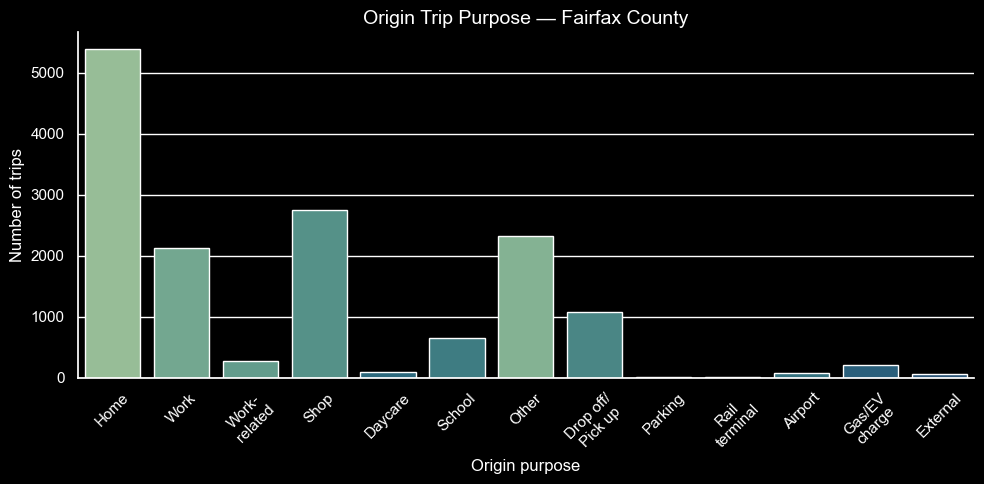

In [67]:
purpose_labels = {
    1: "Home", 2: "Work", 3: "Work-\nrelated", 4: "Shop", 7: "Daycare", 8: "School", 9: "Other",
    11: "Drop off/\nPick up", 13: "Parking", 16: "Rail\nterminal", 17: "Bus\nterminal",
    18: "Airport", 77: "Gas/EV\ncharge", 99: "External",
}
o_purpose_data = trips_df[trips_df["O_PURPOSE"] != -9].copy()
o_purpose_data["OPurpose"] = o_purpose_data["O_PURPOSE"].map(purpose_labels)
o_purpose_order = [purpose_labels[c] for c in sorted(o_purpose_data["O_PURPOSE"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = o_purpose_data, x = "OPurpose", order = o_purpose_order, hue = "OPurpose", palette = "crest", legend = False, ax = ax)
ax.set_title("Origin Trip Purpose — Fairfax County", fontsize = 14)
ax.set_xlabel("Origin purpose")
ax.set_ylabel("Number of trips")
ax.tick_params(axis = "x", rotation = 45)
sns.despine()
plt.tight_layout()
plt.show()

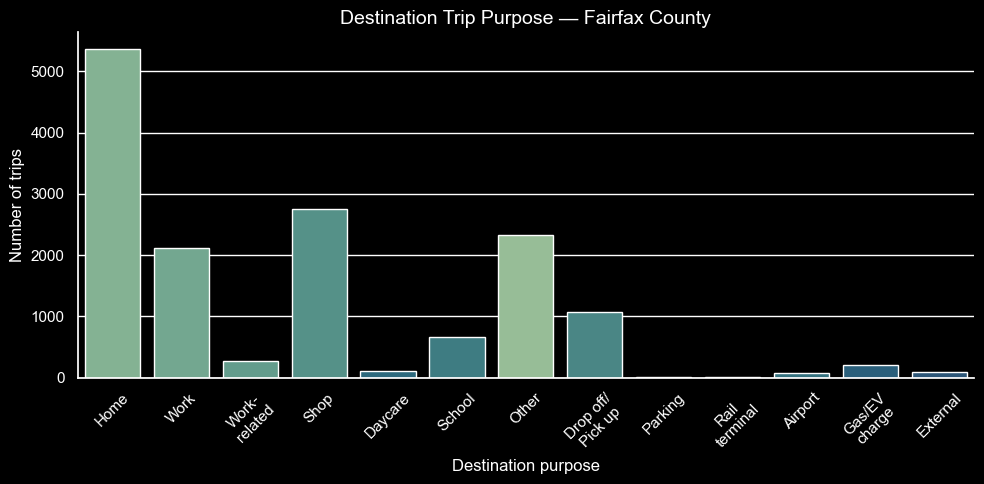

In [68]:
d_purpose_data = trips_df[trips_df["D_PURPOSE"] != -9].copy()
d_purpose_data["DPurpose"] = d_purpose_data["D_PURPOSE"].map(purpose_labels)
d_purpose_order = [purpose_labels[c] for c in sorted(d_purpose_data["D_PURPOSE"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = d_purpose_data, x = "DPurpose", order = d_purpose_order, hue = "DPurpose", palette = "crest", legend = False, ax = ax)
ax.set_title("Destination Trip Purpose — Fairfax County", fontsize = 14)
ax.set_xlabel("Destination purpose")
ax.set_ylabel("Number of trips")
ax.tick_params(axis = "x", rotation = 45)
sns.despine()
plt.tight_layout()
plt.show()

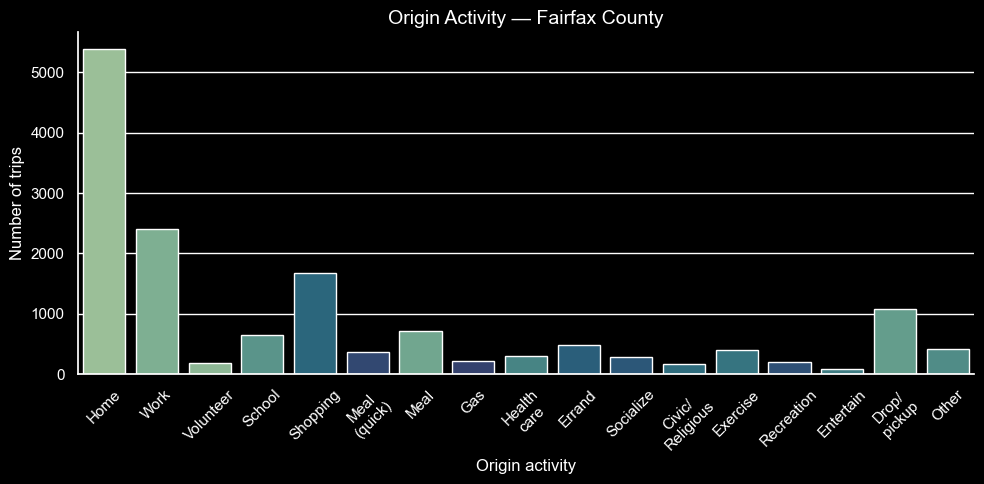

In [69]:
activity_labels = {
    1: "Home", 2: "Work", 3: "Volunteer", 4: "School", 5: "Shopping", 6: "Meal\n(quick)",
    7: "Meal", 8: "Gas", 9: "Health\ncare", 10: "Errand", 11: "Socialize", 12: "Civic/\nReligious",
    13: "Exercise", 14: "Recreation", 15: "Entertain", 16: "Drop/\npickup", 18: "Other",
}
o_activity_data = trips_df[trips_df["O_ACTIVITY"] != -9].copy()
o_activity_data["OActivity"] = o_activity_data["O_ACTIVITY"].map(activity_labels)
o_activity_order = [activity_labels[c] for c in sorted(o_activity_data["O_ACTIVITY"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = o_activity_data, x = "OActivity", order = o_activity_order, hue = "OActivity", palette = "crest", legend = False, ax = ax)
ax.set_title("Origin Activity — Fairfax County", fontsize = 14)
ax.set_xlabel("Origin activity")
ax.set_ylabel("Number of trips")
ax.tick_params(axis = "x", rotation = 45)
sns.despine()
plt.tight_layout()
plt.show()

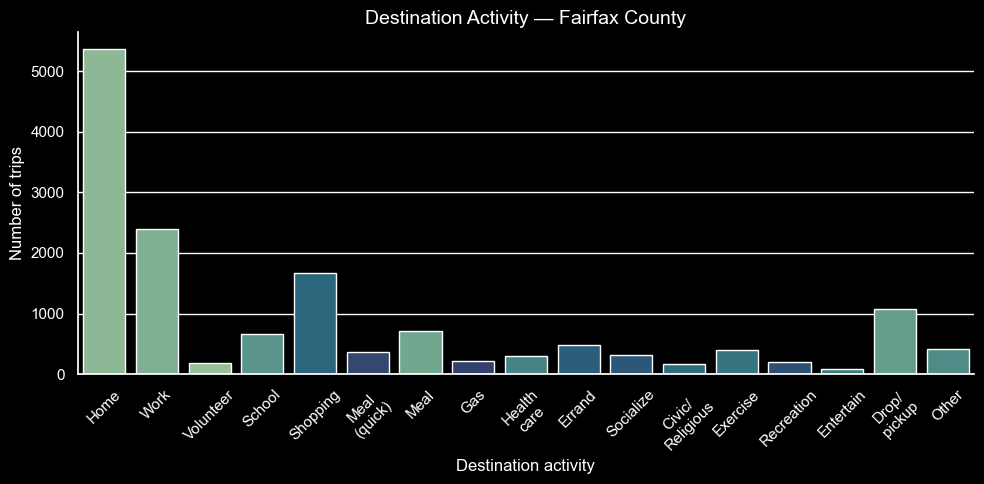

In [70]:
d_activity_data = trips_df[trips_df["D_ACTIVITY"] != -9].copy()
d_activity_data["DActivity"] = d_activity_data["D_ACTIVITY"].map(activity_labels)
d_activity_order = [activity_labels[c] for c in sorted(d_activity_data["D_ACTIVITY"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = d_activity_data, x = "DActivity", order = d_activity_order, hue = "DActivity", palette = "crest", legend = False, ax = ax)
ax.set_title("Destination Activity — Fairfax County", fontsize = 14)
ax.set_xlabel("Destination activity")
ax.set_ylabel("Number of trips")
ax.tick_params(axis = "x", rotation = 45)
sns.despine()
plt.tight_layout()
plt.show()

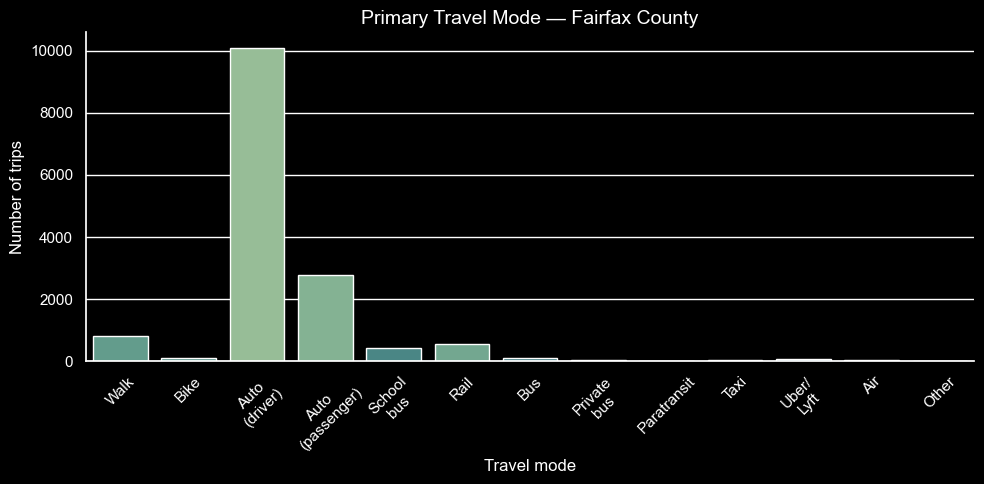

In [71]:
travel_mode_labels = {
    1: "Walk", 2: "Bike", 3: "Motorcycle", 4: "Auto\n(driver)", 5: "Auto\n(passenger)",
    6: "School\nbus", 7: "Rail", 8: "Bus", 9: "Private\nbus", 10: "Paratransit",
    11: "Taxi", 12: "Uber/\nLyft", 13: "Air", 14: "Water", 15: "Other",
}
travel_mode_data = trips_df[trips_df["TRAVEL_MODE"] != -9].copy()
travel_mode_data["TravelMode"] = travel_mode_data["TRAVEL_MODE"].map(travel_mode_labels)
travel_mode_order = [travel_mode_labels[c] for c in sorted(travel_mode_data["TRAVEL_MODE"].unique())]
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = travel_mode_data, x = "TravelMode", order = travel_mode_order, hue = "TravelMode", palette = "crest", legend = False, ax = ax)
ax.set_title("Primary Travel Mode — Fairfax County", fontsize = 14)
ax.set_xlabel("Travel mode")
ax.set_ylabel("Number of trips")
ax.tick_params(axis = "x", rotation = 45)
sns.despine()
plt.tight_layout()
plt.show()

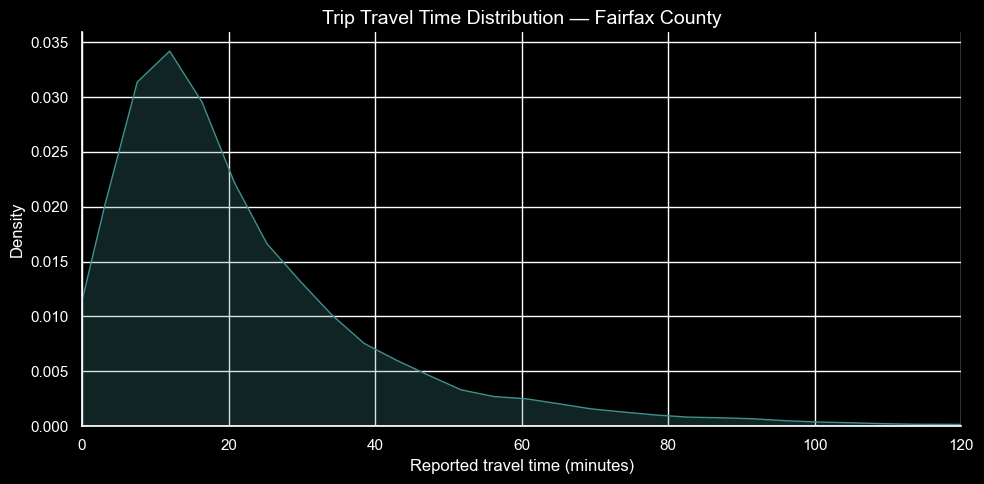

In [72]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.kdeplot(data = trips_df[trips_df["REPORTED_TRAVEL_TIME"] != -9], x = "REPORTED_TRAVEL_TIME", fill = True, color = sns.color_palette("crest")[2], ax = ax)
ax.set_xlim(0, 120)
ax.set_title("Trip Travel Time Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Reported travel time (minutes)")
ax.set_ylabel("Density")
sns.despine()
plt.tight_layout()
plt.show()

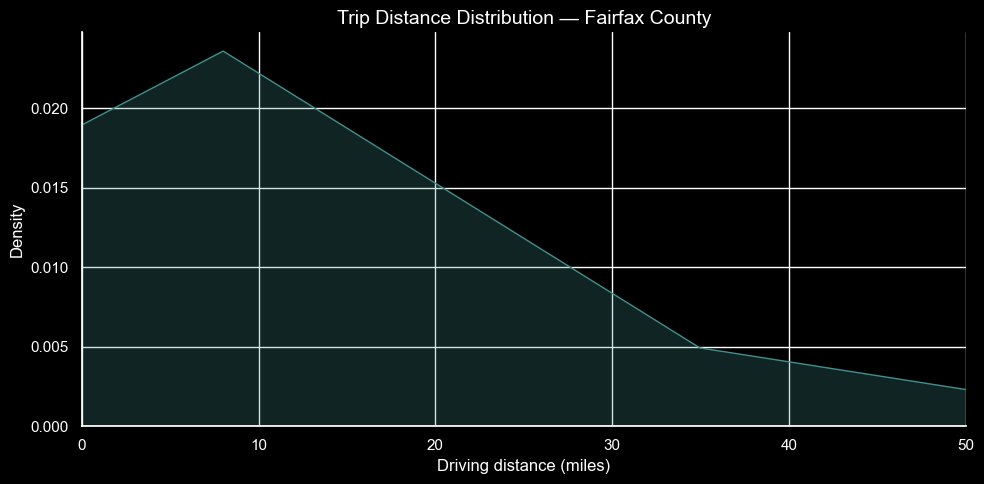

In [73]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.kdeplot(data = trips_df[trips_df["DISTANCE"] != -9], x = "DISTANCE", fill = True, color = sns.color_palette("crest")[2], ax = ax)
ax.set_xlim(0, 50)
ax.set_title("Trip Distance Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Driving distance (miles)")
ax.set_ylabel("Density")
sns.despine()
plt.tight_layout()
plt.show()